<a href="https://colab.research.google.com/github/Rayy505/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import libraries

In [22]:
import numpy as np
from PIL import Image
from google.colab import files
import os
import matplotlib.pyplot as plt

2. Upload image

In [23]:
print("Upload the image you want to filter: ")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Uploaded file "{fn}" with length {len(uploaded[fn])} bytes'.format(name=fn, length=len(uploaded[fn])))

Upload the image you want to filter: 


Saving image_2026-09-27_134353328.png to image_2026-09-27_134353328.png
Uploaded file "image_2026-09-27_134353328.png" with length 110032 bytes


3. Convert image to numpy array

In [24]:
def get_img_array(img_path):
  img = Image.open(img_path).convert('RGB')
  return np.array(img, dtype=np.float32)

4. Helper functions

In [25]:
def get_kernel_params(kernel_size):
  #if kernel size is even, add 1 to make it odd
  if kernel_size % 2 == 0:
    kernel_size += 1

  pad = int(np.floor(kernel_size / 2))
  return kernel_size, pad

In [26]:
def generate_spatial_weights(kernel_size, pad, sigma):
  # Precompute the spatial Gaussian weights
  spatial_weights = np.zeros((kernel_size, kernel_size), dtype=np.float32)

  for i in range(kernel_size):
    for j in range(kernel_size):
      # Map array indices to physical coordinates centered at 0
        x = i - pad
        y = j - pad

        # Calculate the spatial weights
        spatial_weights[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))

  return spatial_weights

In [27]:
def pad_image_array(img_array, pad):
  # Pad the input array to handle image boundaries
  return np.pad(img_array, ((pad, pad), (pad, pad), (0, 0)), mode='edge')

5. Gaussian Blur Algorithm

In [28]:
def gaussian_filter(img_array, kernel_size, sigma):
  h, w, c = img_array.shape

  kernel_size, pad = get_kernel_params(kernel_size)

  kernel = generate_spatial_weights(kernel_size, pad, sigma)
  kernel = kernel / np.sum(kernel)

  gaussian_filtered = np.zeros((h, w, c), dtype=np.float32)

  padded_array = pad_image_array(img_array, pad)

  for ki in range(kernel_size):
    for kj in range(kernel_size):
      shifted_view = padded_array[ki:ki+h, kj:kj+w]
      kernel_weight = kernel[ki, kj]
      gaussian_filtered += shifted_view * kernel_weight

  return gaussian_filtered

6. Bilateral Filtering Algorithm

In [29]:
def bilateral_filter(img_array, kernel_size, sigma_s, sigma_r):
  h, w, c = img_array.shape

  kernel_size, pad = get_kernel_params(kernel_size)

  spatial_weights = generate_spatial_weights(kernel_size, pad, sigma_s)

  bilateral_filtered = np.zeros((h, w, c), dtype=np.float32)
  weight_sum = np.zeros((h, w, c), dtype=np.float32)

  padded_array = pad_image_array(img_array, pad)

  center_view = padded_array[pad:pad+h, pad:pad+w, :]

  #apply kernel
  for ki in range(kernel_size):
    for kj in range(kernel_size):
      shifted_view = padded_array[ki:ki+h, kj:kj+w, :]
      intensity_diff = shifted_view - center_view
      range_weight = np.exp(-intensity_diff**2 / (2 * sigma_r**2))
      weight = spatial_weights[ki, kj] * range_weight

      bilateral_filtered += shifted_view * weight

      #normalize
      weight_sum += weight

  return bilateral_filtered / weight_sum

7. Save, Download, and Display Results

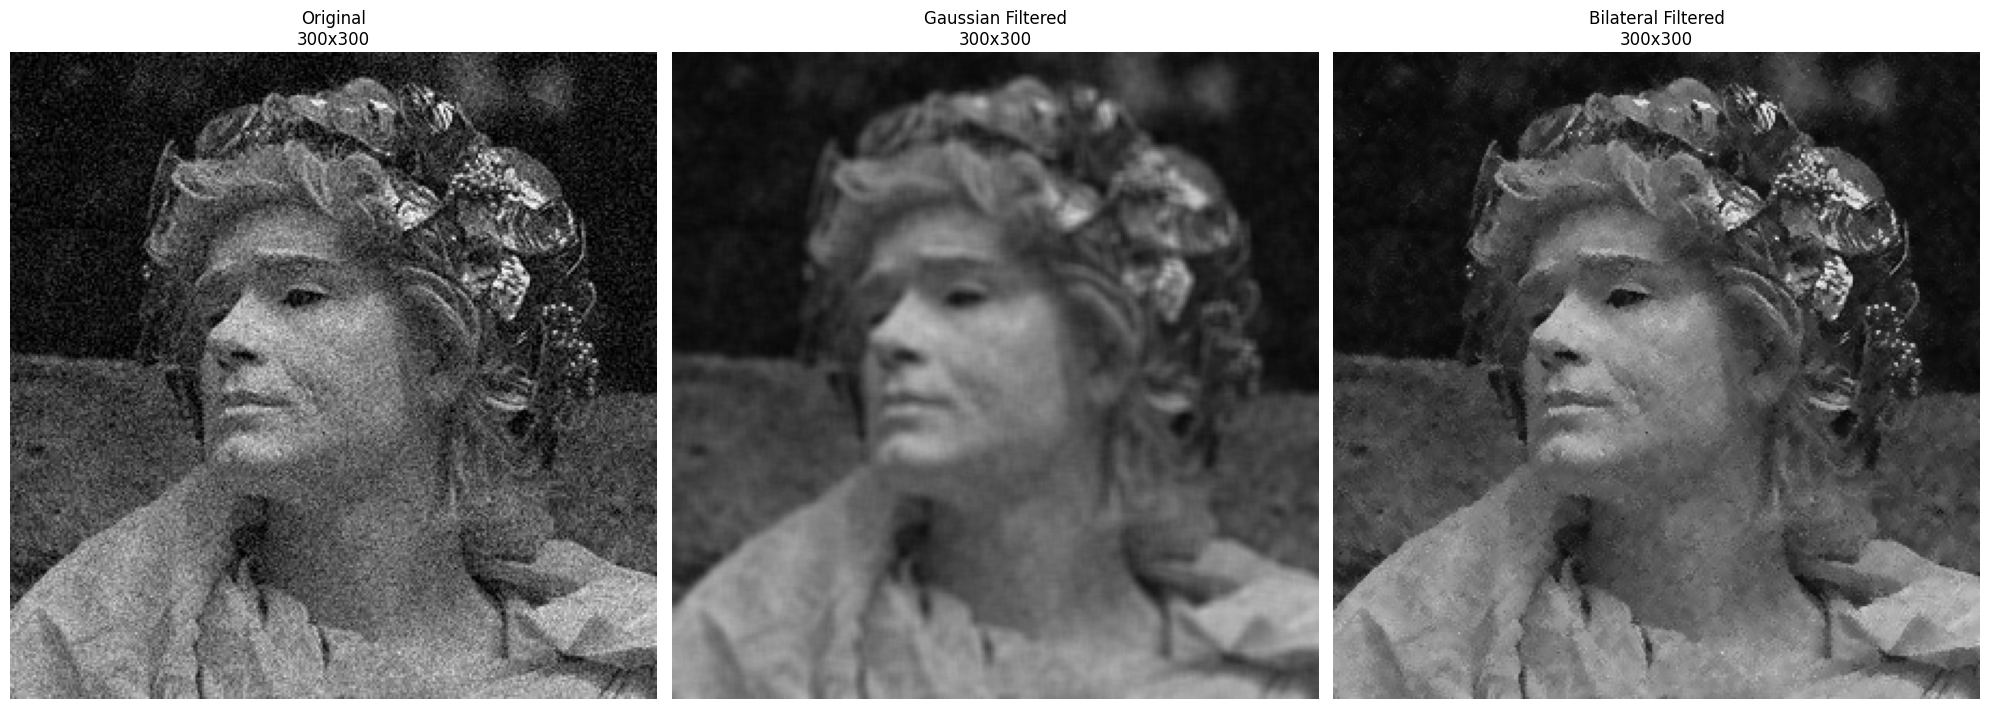

Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads complete!


In [63]:
def save_and_download(img_array, filename):
  if isinstance(img_array, plt.Figure):
    img_array.savefig(filename, bbox_inches='tight', dpi=300)
  else:
    filtered = np.clip(img_array, 0, 255).astype(np.uint8)
    img = Image.fromarray(filtered)
    img.save(filename)
  files.download(filename)

def compare_methods(img_path):
  img_array = get_img_array(img_path)

  gaussian_filtered = gaussian_filter(img_array, 5, 5)
  bilateral_filtered = bilateral_filter(img_array, 5, 5, 25)

  #visualization
  fig, axes = plt.subplots(1, 3, figsize=(20, 15))

  row1 = [("Original", img_array), ("Gaussian Filtered", gaussian_filtered), ("Bilateral Filtered", bilateral_filtered)]
  for i, (title, data) in enumerate(row1):
    axes[i].imshow(np.clip(data, 0, 255).astype(np.uint8))
    axes[i].set_title(f"{title}\n{data.shape[1]}x{data.shape[0]}")
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

  #downloads
  print("Starting downloads...")
  save_and_download(gaussian_filtered, "gaussian.png")
  save_and_download(bilateral_filtered, "bilateral.png")
  save_and_download(fig, "plot.png")
  print("Downloads complete!")

if 'fn' in locals():
  compare_methods(fn)
else:
  print("Could not locate fn in the current directory")